In [1]:
## load packages 

from pysankey import sankey
import pandas as pd
import json, requests 
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from tqdm import tqdm
import time

import unicodedata
from metaphone import doublemetaphone
from fuzzywuzzy import fuzz
from difflib import SequenceMatcher
import re

import plotly.express as px
import pickle
import random 

import psycopg2
from collections import Counter

from shapely.geometry import Point
from shapely.geometry import mapping
from shapely.geometry.polygon import Polygon
import json

import matplotlib.colors as plc
import pydeck as pdk


/home/fs01/spec1142/anaconda3/envs/patents2/lib/python3.9/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [2]:
## load database username and password

main_path = "/home/fs01/spec1142/Emma/GateKeepers/"

f = open('/home/fs01/spec1142/Emma/GateKeepers/' + "database.txt", "r")
user , password = f.read().split()

In [3]:
path = "/home/fs01/spec1142/Emma/GateKeepers/"  + "gatekeepers_intermediate_clean_v5.tsv"
df_scientists_inventors = pd.read_csv(path , delimiter = '\t'  )

In [4]:
df_scientists_inventors['conf'] = df_scientists_inventors['number of match'] / df_scientists_inventors['number of comparison']
df_scientists_inventors = df_scientists_inventors[df_scientists_inventors['conf'] > 0.5 ]

In [5]:
df_scientists_invento

,inventor_id,author_id,number of comparison,number of match,author_name,inventor_name,name score,flag,number of papers,number of patents,conf
0,fl:vl_ln:agabekov-1,A5021674115,388,347,v e agabekov,vladimir enokovich agabekov,0.646114,0,169.0,4.0,0.894330
1,fl:vl_ln:agabekov-1,A5064385225,540,443,v e agabekov,vladimir enokovich agabekov,0.646114,0,140.0,4.0,0.820370
2,fl:dr_ln:antonijevic-1,A5056102017,174,91,dragi antonijevic,dragi antonijevic,0.651495,0,32.0,6.0,0.522989
3,fl:sa_ln:antonijevic-1,A5067440233,28,27,sasa antonijevic,sasa antonijevic,0.666145,0,32.0,1.0,0.964286
4,fl:bl_ln:ardman-1,A5023903278,64,57,blair ardman,blair ardman,0.688878,0,32.0,2.0,0.890625
...,...,...,...,...,...,...,...,...,...,...,...
1269719,fl:al_ln:soler-1,A5024790448,256,178,alejandro peralta soler,alejandro peralta soler,0.752175,0,141.0,2.0,0.695312
1269721,fl:al_ln:soler-3,A5080066151,78,60,alan soler,alan i soler,0.616307,0,95.0,1.0,0.769231
1269722,fl:mi_ln:soler-1,A5070646216,60,40,michel soler,michel soler,0.617021,0,26.0,3.0,0.666667
1269723,rlbwhsz8mj0z72wx1wfqqahsj,A5064418813,43,34,dulce soler,dulce soler,0.566358,0,46.0,1.0,0.790698


## Inventors location

### Inventors - year - counties 

In [38]:
inventor_PatentsView = pd.read_csv(main_path+ "download_PatentsView/g_inventor_disambiguated.tsv" , sep= "\t")

In [39]:
len(set(list(inventor_PatentsView['inventor_id'])))

3959261

In [5]:
locations_PatentsView = pd.read_csv(main_path + "download_PatentsView/g_location_disambiguated.tsv" , sep= "\t")


In [6]:
location_inventors_PatentsView = inventor_PatentsView.merge(locations_PatentsView, on='location_id' , how = 'left')

In [7]:
patents_PatentsView = pd.read_csv(main_path + "download_PatentsView/g_patent.tsv" , sep= "\t", usecols = ['patent_id','patent_date'])


/tmp/ipykernel_999562/1203210299.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  patents_PatentsView = pd.read_csv("/home/fs01/spec1142/Emma/GateKeepers/" + "download_PatentsView/g_patent.tsv" , sep= "\t", usecols = ['patent_id','patent_date'])


In [8]:
location_inventors_PatentsView['patent_id'] = location_inventors_PatentsView['patent_id'].astype(str)
patents_PatentsView['patent_id'] = patents_PatentsView['patent_id'].astype(str)

In [9]:
location_inventors_PatentsView = location_inventors_PatentsView.merge(patents_PatentsView, on='patent_id' , how = 'left')

IOStream.flush timed out


In [13]:
location_inventors_PatentsView[['patent_id','patent_date', 'inventor_id',
       'disambig_country','county', 'state_fips',
       'county_fips']].to_csv(main_path + "data_description/inventors_geographic_location.tsv", sep = "\t" , index = False)

In [5]:
location_inventors_PatentsView = pd.read_csv(main_path + "data_description/inventors_geographic_location.tsv", sep = "\t" )

In [6]:
location_inventors_PatentsView = location_inventors_PatentsView[['patent_id','patent_date', 'inventor_id',
       'disambig_country','county', 'state_fips',
       'county_fips']]

In [7]:
dic_location_inventors_PatentsView = location_inventors_PatentsView.to_dict('index')

In [8]:
dic_data_inventors = {} 
set_SIs = set(list(df_scientists_inventors['inventor_id']))

for elem in tqdm(dic_location_inventors_PatentsView):
    inventor_id = dic_location_inventors_PatentsView[elem]['inventor_id']
    if inventor_id not in set_SIs:
        year = dic_location_inventors_PatentsView[elem]['patent_date'][:4]
        if inventor_id + " " + year not in dic_data_inventors:
            dic_data_inventors[inventor_id + " " + year] = {}
            dic_data_inventors[inventor_id + " " + year]['inventor_id'] = inventor_id
            dic_data_inventors[inventor_id + " " + year]['year'] = int(year)
            dic_data_inventors[inventor_id + " " + year]['country'] = []
            dic_data_inventors[inventor_id + " " + year]['fips']  = []
        
        dic_data_inventors[inventor_id + " " + year]['country'].append(dic_location_inventors_PatentsView[elem]['disambig_country'])
        if pd.isna(dic_location_inventors_PatentsView[elem]['state_fips']) == False and pd.isna(dic_location_inventors_PatentsView[elem]['county_fips']) == False and dic_location_inventors_PatentsView[elem]['county_fips'] != None and dic_location_inventors_PatentsView[elem]['state_fips'] != None:
            dic_data_inventors[inventor_id + " " + year]['fips'].append(str(int(dic_location_inventors_PatentsView[elem]['state_fips'])).zfill(2) + str(int(dic_location_inventors_PatentsView[elem]['county_fips'])).zfill(3))
    
    


100%|████████████████████████████| 21197038/21197038 [05:36<00:00, 63005.02it/s]


In [9]:
## function which return the most frequent element of a list
def most_frequent(List):
    if List != []:
        random.shuffle(List)
        occurence_count = Counter(List)
        return occurence_count.most_common(1)[0][0]
    else:
        return None

for elem in tqdm(dic_data_inventors):
    dic_data_inventors[elem]['main_country'] = most_frequent(dic_data_inventors[elem]['country'])
    dic_data_inventors[elem]['main_fips'] = most_frequent(dic_data_inventors[elem]['fips'])
    

100%|████████████████████████████| 10170472/10170472 [02:50<00:00, 59505.27it/s]


In [11]:
dic_data_inventors2 = {}

for elem in tqdm(dic_data_inventors):
    dic_data_inventors2[elem] = {}
    dic_data_inventors2[elem]['year'] = dic_data_inventors[elem]['year']
    dic_data_inventors2[elem]['inventor_id'] = dic_data_inventors[elem]['inventor_id']
    dic_data_inventors2[elem]['main_country'] = dic_data_inventors[elem]['main_country']
    dic_data_inventors2[elem]['main_fips'] = dic_data_inventors[elem]['main_fips']
    

In [12]:
import json
json = json.dumps(dic_data_inventors2)
f = open(main_path + "data_description/data/inventors_counties.json","w")
f.write(json)
f.close()

In [34]:
inventors = []
for elem in tqdm(dic_data_inventors2):
    inventors.append(dic_data_inventors2[elem]['inventor_id'])

100%|███████████████████████████| 10170472/10170472 [00:27<00:00, 375026.01it/s]


In [35]:
len(set(inventors))

3366577

### Plots

#### Top countries

In [ ]:
f = open(main_path + "data_description/data/inventors_counties.json","r")
import json
dic_data_inventors = json.load(f)

In [13]:
dic_counts = {} 

for elem in tqdm(dic_data_inventors):
    country = dic_data_inventors[elem]["main_country"]
    if country not in dic_counts:
        dic_counts[country] = 0 
    dic_counts[country] += 1

dic_counts = { k : v for k,v in sorted(dic_counts.items() , key= lambda item: item[1], reverse = True)}


100%|███████████████████████████| 10170472/10170472 [00:22<00:00, 442925.46it/s]


In [14]:
countries = [ 'US','JP','DE','FR','GB','KR','CA']

dic_counts_main = { k : dic_counts[k] for k in countries }
others = sum( { k : dic_counts[k] for  k in dic_counts if k not in countries }.values() )

In [15]:
dic_counts_main['other'] = others

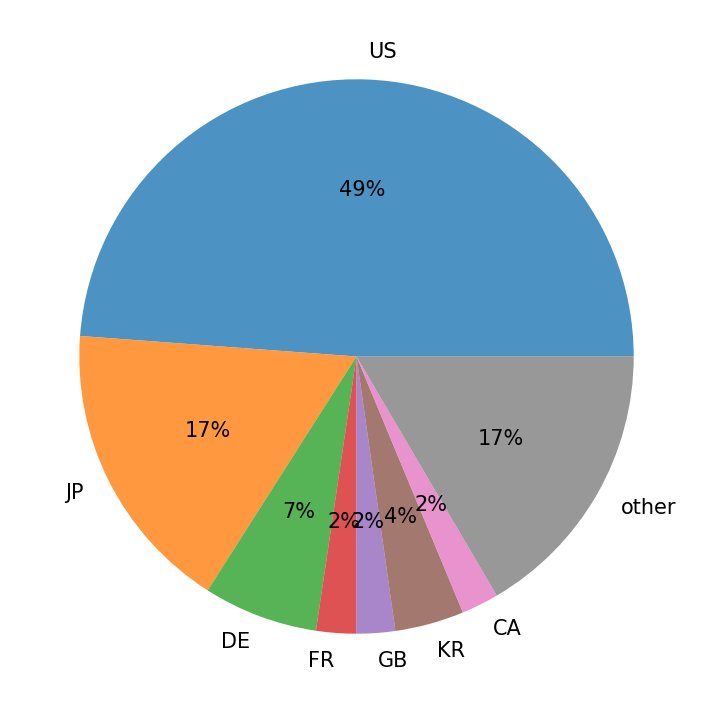

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize = (9,9))
countries = [ 'US','JP','DE','FR','GB','KR','CA' , 'other'] 
y = [ dic_counts_main[elem] for elem in countries]

plt.pie(y, labels = countries,autopct='%1.f%%', textprops={'fontsize': 15}, wedgeprops={"alpha": 0.8})
plt.show() 

#### Top counties

In [17]:
dic_counts = {} 

for elem in tqdm(dic_data_inventors):
    country = dic_data_inventors[elem]["main_fips"]
    if country not in dic_counts:
        dic_counts[country] = 0 
    dic_counts[country] += 1

dic_counts = { k : v for k,v in sorted(dic_counts.items() , key= lambda item: item[1], reverse = True)}


100%|███████████████████████████| 10170472/10170472 [00:25<00:00, 403941.47it/s]


In [18]:
counties =list(dic_counts.keys())[1:10]
dic_counts_main = { k : dic_counts[k] for k in counties }
others = sum( { k : dic_counts[k] for  k in dic_counts if k not in counties and k != None }.values() )

dic_counts_main['other'] = others

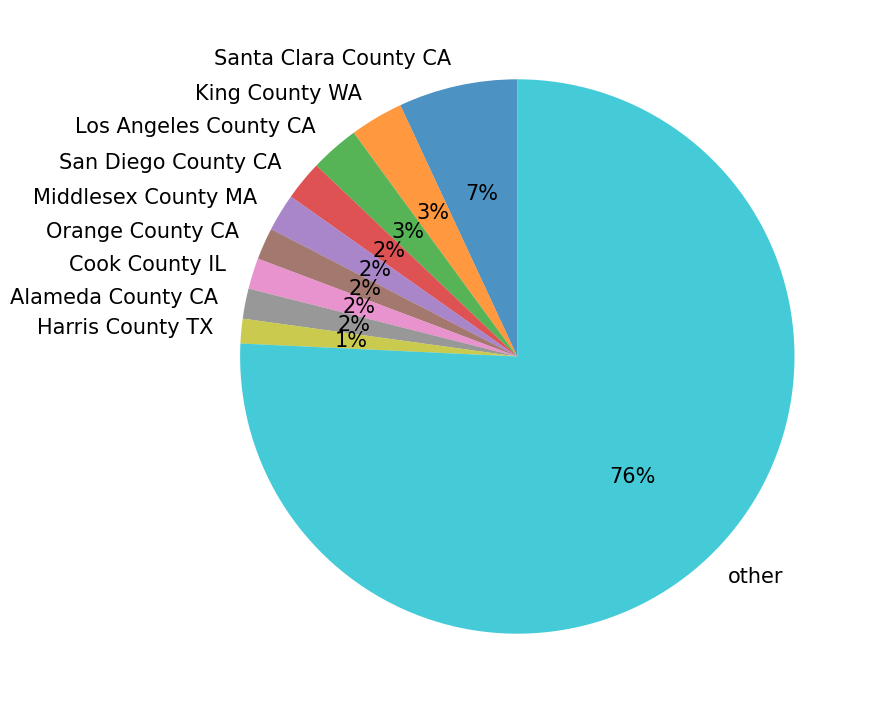

In [20]:
import matplotlib.pyplot as plt
import numpy as np

geo_file = pd.read_csv(main_path + "data_description/data/us-county-boundaries.csv" , delimiter = ";")
dic_counties = geo_file[['GEOID','NAMELSAD','STUSAB']].set_index('GEOID').to_dict('index')


plt.figure(figsize = (9,9))



list_labels = [ dic_counties[int(elem)]['NAMELSAD'] + " " + dic_counties[int(elem)]['STUSAB'] for elem in counties  ] + ["other"]

y = [ dic_counts_main[elem] for elem in counties] +  [ dic_counts_main["other"] ] 
plt.pie(y, labels = list_labels ,autopct='%1.f%%', textprops={'fontsize': 15}, wedgeprops={"alpha": 0.8},startangle=90)
plt.show() 

#### Top counties over time

In [21]:
## for each fips, get number of active SIs per year 

dic_year_counties = { } 

for elem in tqdm(list(dic_data_inventors.keys())):
    fips = dic_data_inventors[elem]['main_fips']
    year = dic_data_inventors[elem]['year']
    if fips != None:
        
        fips = int(fips)
        if fips not in dic_year_counties:
            dic_year_counties[fips] = { year : 0 for year in range(1980,2023) } 
        if year in dic_year_counties[fips]:
            dic_year_counties[fips][year] += 1


100%|███████████████████████████| 10170472/10170472 [00:36<00:00, 281314.47it/s]


In [22]:
## for each year, get number of active SIs
## for each year, get the proportion of SIs in each county

dic_tot = { year : 0 for year in range(1980,2023) } 

for county in dic_year_counties:
    for year in dic_year_counties[county]:
        dic_tot[year] += dic_year_counties[county][year]
        
        
for county in dic_year_counties:
    for year in dic_year_counties[county]:
        dic_year_counties[county][year]  = 100*dic_year_counties[county][year] / dic_tot[year]

## sort the county by descending proportion 
dic_year_counties_sorted = { k : v for k,v in sorted(dic_year_counties.items(), key=lambda item: sum(item[1].values()) , reverse = True) }


100%|███████████████████████████████████████████| 31/31 [00:00<00:00, 92.02it/s]


Text(0.5, 1.0, 'Proportion of the inventors in the top 31 counties')

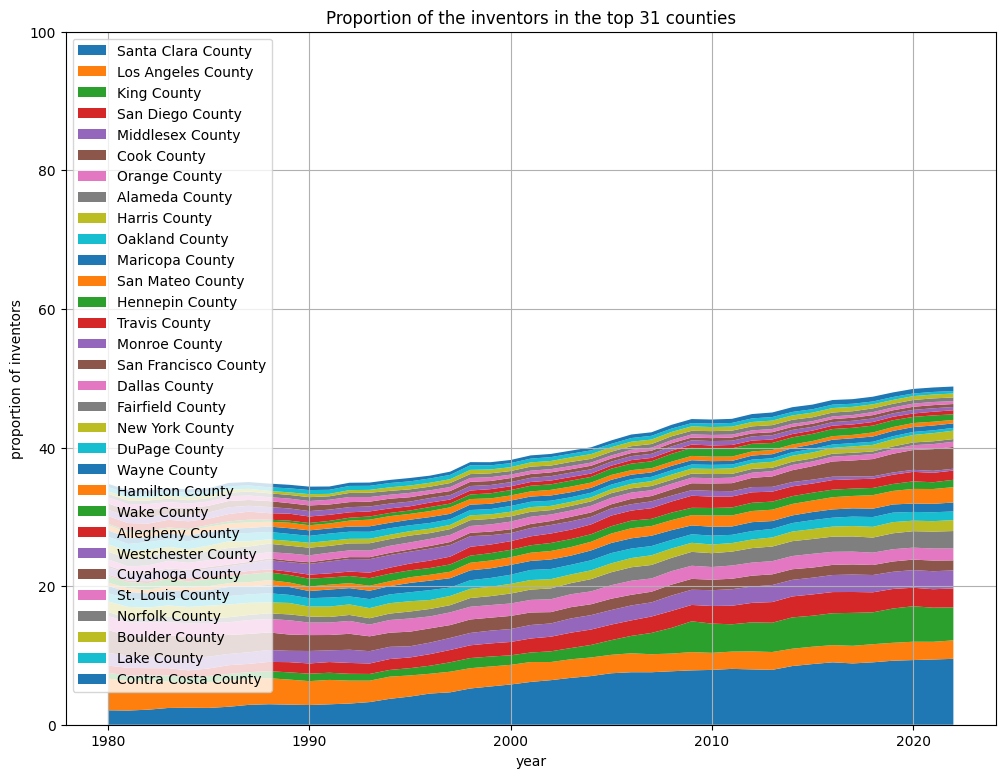

In [23]:
## plot the proportion of SIs in the top 1% counties

list_10_counties = list(dic_year_counties_sorted.keys())[:31]


plt.figure(figsize = (12,9))
legend = []
pre_county = np.zeros((2023-1980))


num_plots = 31


k = 0 

for county in tqdm(list_10_counties):
    k = np.random.randint(0,num_plots)
    plt.fill_between(dic_year_counties_sorted[county].keys() , np.array(list(dic_year_counties_sorted[county].values())) + pre_county   , pre_county  )
    pre_county = np.array(list(dic_year_counties_sorted[county].values())) + pre_county
    legend.append(geo_file[geo_file["GEOID"] == int(county)]["NAMELSAD"].tolist()[0])
    k += 1
    
    
plt.legend(legend , loc="upper left")
plt.grid()
plt.xlabel("year")
plt.ylim([0,100])
plt.ylabel("proportion of inventors")
plt.title("Proportion of the inventors in the top 31 counties")

In [24]:
dic_year_inventors = {}

for county in dic_year_counties_sorted:
    for year in dic_year_counties_sorted[county]:
        if year not in dic_year_inventors:
            dic_year_inventors[year] = {}
        if county not in dic_year_inventors[year]:
            dic_year_inventors[year][county] = { 'values' : dic_year_counties[county][year] }

100%|█████████████████████████████████████████████| 1/1 [00:04<00:00,  4.39s/it]


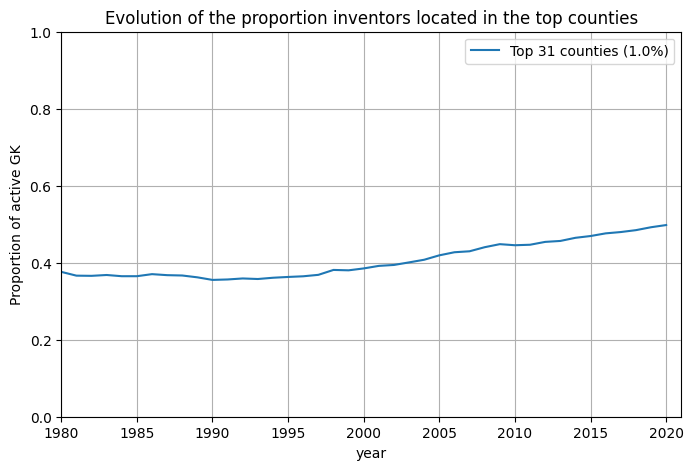

In [25]:
## plot proportion of SIs for different % of counties 

plt.figure(figsize = (8,5))
legend = [] 
for value in tqdm([31]):

    X = [ year for year in range(1980,2021)]
    Y = []
    for year in range(1980,2021):
        df_gk = pd.DataFrame(dic_year_inventors[year]).T.sort_values("values" , ascending = False)

        sum_gk = sum(df_gk["values"])

        prop = sum(df_gk.head(value)["values"])/sum_gk
        Y.append(prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.plot(X,Y)
    
plt.legend(legend)
plt.ylim([0,1])
plt.xlim([1980,2021])
plt.xlabel("year")
plt.ylabel("Proportion of active GK") 
plt.title("Evolution of the proportion inventors located in the top counties")
plt.grid()
plt.show()

In [26]:
import json
json = json.dumps(dic_year_inventors)
f = open(main_path + "data_description/data/dic_year_inventor.json","w")
f.write(json)
f.close()

## Scientists location

### Get all scientists - year - institution

In [4]:
f = open(main_path + "regressions/dic_papers_citations.json","r")
import json
dic = json.load(f)

NameError: name 'main_path' is not defined

In [12]:
dic_authors = {}

for elem in tqdm(dic):
    authors = dic[elem]['authors']
    year = dic[elem]['year']
    for author in authors: 
        if author not in dic_authors:
            dic_authors[author] = {}
        if year not in dic_authors[author]:
            dic_authors[author][year] = {}
        institution = random.choice(dic[elem]['institutions'])
        dic_authors[author][year]['institution'] = institution
                

100%|████████████████████████████| 21458438/21458438 [16:34<00:00, 21576.85it/s]


In [21]:
import json
json = json.dumps(dic_authors)
f = open(main_path + "data_description/data/authors_counties.json","w")
f.write(json)
f.close()

### Count scientists by counties 

In [5]:
f = open(main_path + "data_description/data/authors_counties.json","r")
import json
dic_authors = json.load(f)

In [101]:
table_institutions = pd.read_csv(main_path + "data_description/data/institutions_up_to_20230817_fips.tsv" , delimiter = "\t" , index_col = 0)


In [7]:
dic_institutions = table_institutions[['fips']].to_dict('index')

In [8]:
len(dic_authors)

11458836

In [9]:
set_SIs= set(list(df_scientists_inventors['author_id']))
len(set_SIs)

660984

In [10]:
## for each fips, get number of active SIs per year 
i = 0 
workers = 1

dic_year_institutions = { } 
list_elem = list(dic_authors.keys())
for k in tqdm(range(i,len(list_elem),workers)):
    elem = list_elem[k]
    if elem not in set_SIs:
        for year in dic_authors[elem]:
            institution = dic_authors[elem][year]['institution']
            if institution != None:
                if institution not in dic_year_institutions:
                    dic_year_institutions[institution] = {}
                if year not in dic_year_institutions[institution]:
                    dic_year_institutions[institution][year] = 0 
                dic_year_institutions[institution][year] += 1
    


100%|███████████████████████████| 11458836/11458836 [01:44<00:00, 109573.12it/s]


In [63]:
dic_year_counties = {}
count = 0 
for institution in tqdm(dic_year_institutions):
    if institution in dic_institutions:
        fips = dic_institutions[institution]['fips']
        if fips != None and pd.isna(fips) == False:
            fips = int(fips)
            if fips not in dic_year_counties:
                dic_year_counties[fips] = { year : 0 for year in range(1980,2023)}
            for year in dic_year_institutions[institution]:
                year = int(year)
                if year in dic_year_counties[fips]:
                    dic_year_counties[fips][year] += len(dic_year_counties[fips])
                    count += len(dic_year_counties[fips])
count
        

100%|██████████████████████████████████| 74045/74045 [00:01<00:00, 43082.46it/s]


20089987

### Plots

#### Top counties

In [64]:
dic_counts = {} 

for elem in tqdm(dic_year_counties):
    country = str(elem)
    if country not in dic_counts:
        dic_counts[country] = 0 
    for year in dic_year_counties[elem]:
        dic_counts[country] += dic_year_counties[elem][year]

dic_counts = { k : v for k,v in sorted(dic_counts.items() , key= lambda item: item[1], reverse = True)}


100%|████████████████████████████████████| 1669/1669 [00:00<00:00, 35296.19it/s]


In [65]:
counties =list(dic_counts.keys())[1:10]
dic_counts_main = { k : dic_counts[k] for k in counties }
others = sum( { k : dic_counts[k] for  k in dic_counts if k not in counties and k != None }.values() )

dic_counts_main['other'] = others

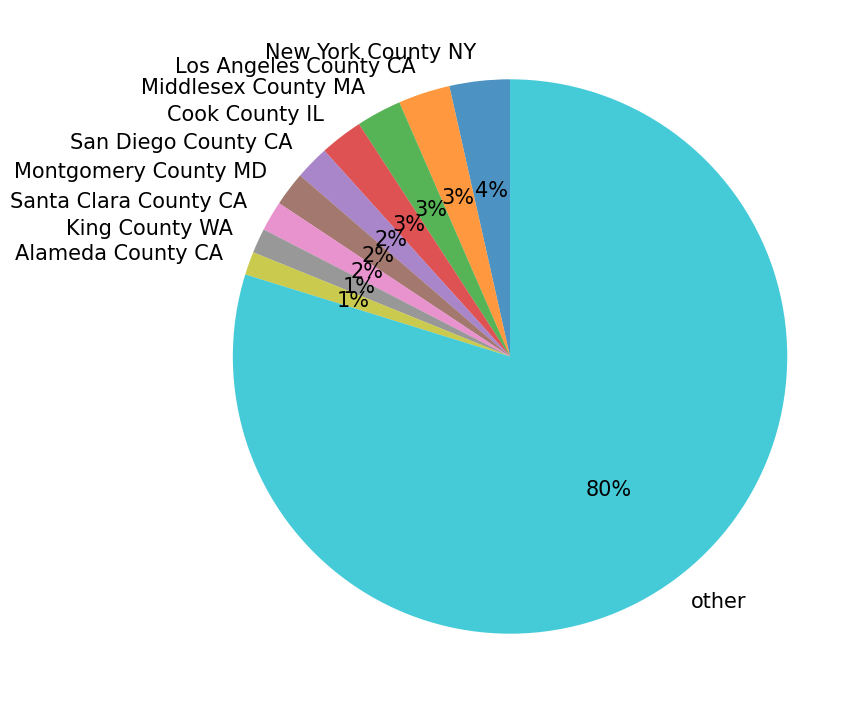

In [38]:
import matplotlib.pyplot as plt
import numpy as np

geo_file = pd.read_csv(main_path + "data_description/data/us-county-boundaries.csv" , delimiter = ";")
dic_counties = geo_file[['GEOID','NAMELSAD','STUSAB']].set_index('GEOID').to_dict('index')


plt.figure(figsize = (9,9))



list_labels = [ dic_counties[int(elem)]['NAMELSAD'] + " " + dic_counties[int(elem)]['STUSAB'] for elem in counties  ] + ["other"]

y = [ dic_counts_main[elem] for elem in counties] +  [ dic_counts_main["other"] ] 
plt.pie(y, labels = list_labels ,autopct='%1.f%%', textprops={'fontsize': 15}, wedgeprops={"alpha": 0.8},startangle=90)
plt.show() 

#### Top counties over time

In [68]:
## for each year, get number of active SIs
## for each year, get the proportion of SIs in each county

dic_tot = { year : 0 for year in range(1980,2023) } 

for county in dic_year_counties:
    for year in dic_year_counties[county]:
        dic_tot[year] += dic_year_counties[county][year]
        
        
for county in dic_year_counties:
    for year in dic_year_counties[county]:
        dic_year_counties[county][year]  = 100*dic_year_counties[county][year] / dic_tot[year]

## sort the county by descending proportion 
dic_year_counties_sorted = { k : v for k,v in sorted(dic_year_counties.items(), key=lambda item: sum(item[1].values()) , reverse = True) }


100%|██████████████████████████████████████████| 31/31 [00:00<00:00, 292.30it/s]


Text(0.5, 1.0, 'Proportion of the scientists in the top 31 counties')

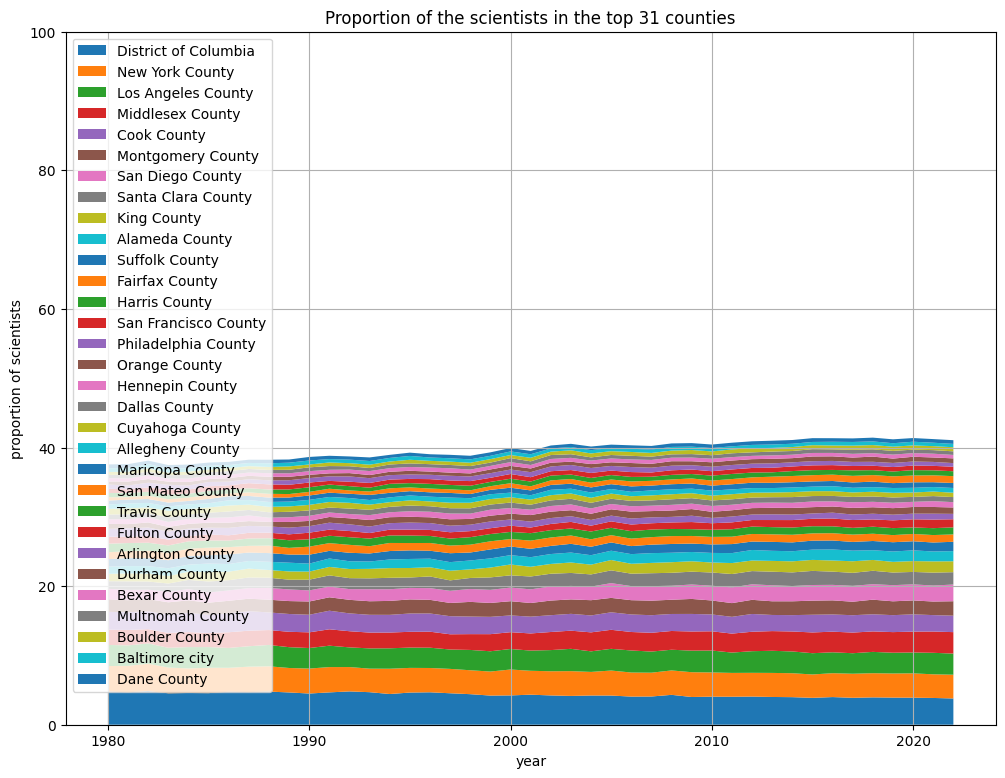

In [69]:
## plot the proportion of SIs in the top 1% counties
geo_file = pd.read_csv(main_path + "data_description/data/us-county-boundaries.csv" , delimiter = ";")

list_10_counties = list(dic_year_counties_sorted.keys())[:31]


plt.figure(figsize = (12,9))
legend = []
pre_county = np.zeros((2023-1980))


num_plots = 31


k = 0 

for county in tqdm(list_10_counties):
    k = np.random.randint(0,num_plots)
    plt.fill_between(dic_year_counties_sorted[county].keys() , np.array(list(dic_year_counties_sorted[county].values())) + pre_county   , pre_county  )
    pre_county = np.array(list(dic_year_counties_sorted[county].values())) + pre_county
    legend.append(geo_file[geo_file["GEOID"] == int(county)]["NAMELSAD"].tolist()[0])
    k += 1
    
    
plt.legend(legend , loc="upper left")
plt.grid()
plt.xlabel("year")
plt.ylim([0,100])
plt.ylabel("proportion of scientists")
plt.title("Proportion of the scientists in the top 31 counties")

In [70]:
dic_year_counties = {}
count = 0 
for institution in tqdm(dic_year_institutions):
    if institution in dic_institutions:
        fips = dic_institutions[institution]['fips']
        if fips != None and pd.isna(fips) == False:
            fips = int(fips)
            if fips not in dic_year_counties:
                dic_year_counties[fips] = { year : 0 for year in range(1980,2023)}
            for year in dic_year_institutions[institution]:
                year = int(year)
                if year in dic_year_counties[fips]:
                    dic_year_counties[fips][year] += len(dic_year_counties[fips])
                    count += len(dic_year_counties[fips])
count
        

100%|██████████████████████████████████| 74045/74045 [00:01<00:00, 51060.83it/s]


20089987

In [71]:
dic_year_authors = {}

for county in dic_year_counties_sorted:
    for year in dic_year_counties_sorted[county]:
        if year not in dic_year_authors:
            dic_year_authors[year] = {}
        if county not in dic_year_authors[year]:
            dic_year_authors[year][county] = { 'values' : dic_year_counties[county][year] }

100%|█████████████████████████████████████████████| 1/1 [00:02<00:00,  2.34s/it]


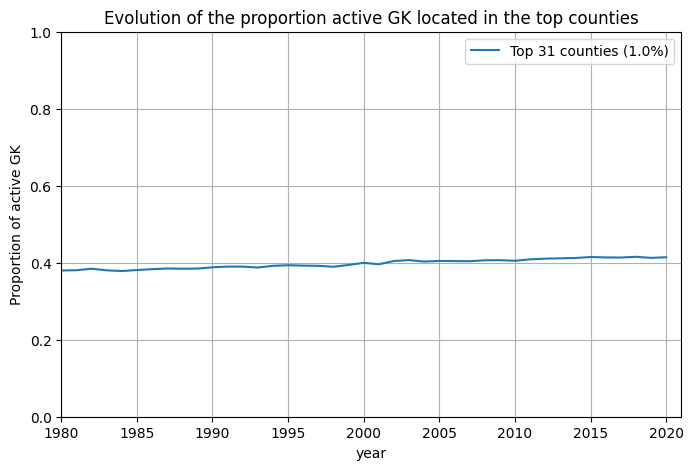

In [76]:
## plot proportion of SIs for different % of counties 

plt.figure(figsize = (8,5))
legend = [] 
for value in tqdm([31]):

    X = [ year for year in range(1980,2021)]
    Y = []
    for year in range(1980,2021):
        df_gk = pd.DataFrame(dic_year_authors[year]).T.sort_values("values" , ascending = False)

        sum_gk = sum(df_gk["values"])

        prop = sum(df_gk.head(value)["values"])/sum_gk
        Y.append(prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.plot(X,Y)
    
plt.legend(legend)
plt.ylim([0,1])
plt.xlim([1980,2021])
plt.xlabel("year")
plt.ylabel("Proportion of active GK") 
plt.title("Evolution of the proportion active GK located in the top counties")
plt.grid()
plt.show()

In [77]:
import json
json = json.dumps(dic_year_authors)
f = open(main_path + "data_description/data/dic_year_author.json","w")
f.write(json)
f.close()

## PQRs

In [28]:
## load data on SIs.
## for each SI inventor_ids and author_ids, 'dic_cluster' gather information about patents and papers,(active years, first active year, and other relevant attributes

f = open(main_path + "data_description/data/dic_clusters_mag_05.json","r")
import json
dic_clusters = json.load(f)

In [29]:
##  geo_file - counties - polygon

geo_file = pd.read_csv(main_path + "data_description/data/us-county-boundaries.csv" , delimiter = ";")

table_institutions = pd.read_csv(main_path + "data_description/data/institutions_up_to_20230817.tsv" , delimiter = "\t" , index_col = 0)
dic_institutions = table_institutions.to_dict("index")


In [30]:
## for each fips, get number of active SIs per year 

dic_year_counties = { } 

for count in tqdm(list(dic_clusters.keys())):
    if "year_fips" in dic_clusters[count]:
        year_county_fips = dic_clusters[count]["year_fips"]
        
        for elem in year_county_fips:
            gatekeeper_year ,  fips = elem
            if fips != '' and pd.isna(fips) == False:
                fips = int(fips)
                if fips not in dic_year_counties:
                    dic_year_counties[fips] = { year : 0 for year in range(1980,2023) } 
                if gatekeeper_year in dic_year_counties[fips]:
                    dic_year_counties[fips][gatekeeper_year] += 1


100%|███████████████████████████████| 581566/581566 [00:03<00:00, 188340.87it/s]


In [31]:
## for each year, get number of active SIs
## for each year, get the proportion of SIs in each county

dic_tot = { year : 0 for year in range(1980,2023) } 

for county in dic_year_counties:
    for year in dic_year_counties[county]:
        dic_tot[year] += dic_year_counties[county][year]
        
        
for county in dic_year_counties:
    for year in dic_year_counties[county]:
        dic_year_counties[county][year]  = 100*dic_year_counties[county][year] / dic_tot[year]

## sort the county by descending proportion 
dic_year_counties_sorted = { k : v for k,v in sorted(dic_year_counties.items(), key=lambda item: sum(item[1].values()) , reverse = True) }


In [42]:
## for each year, get the number of SI by county.

dic_gk = { year : {} for year in range(1980,2022) } 
concept_0 = "Computer science"

for count in tqdm(dic_clusters.keys()):
    #if "year_fips" in dic_clusters[count] and  str(count) in dic_concepts_cpcs and dic_concepts_cpcs[str(count)]['concept'] == concept_0 :
    if "year_fips" in dic_clusters[count]:
   
        gatekeeper_years = dic_clusters[count]["year_fips"]
        
        for elem in gatekeeper_years:
            gatekeeper_year , fips   = elem
            if pd.isna(fips) == False:
                fips = int(fips)
        
            if gatekeeper_year in dic_gk:

                if fips not in dic_gk[gatekeeper_year]:
                    dic_gk[gatekeeper_year][fips] = {}
                    dic_gk[gatekeeper_year][fips]["Fips"] = fips
                    dic_gk[gatekeeper_year][fips]["values"] = 0
                dic_gk[gatekeeper_year][fips]["values"] += 1

geo_file["fips"] = [ str(elem[0]).zfill(2) + str(elem[1]).zfill(3) for elem in geo_file[["STATEFP","COUNTYFP"]].to_numpy()]
geo_file["country_state"] = [ elem[0] + " " + elem[1] for elem in geo_file[["NAMELSAD","STUSAB"]].to_numpy()]


year = 2020
df_gk = pd.DataFrame(dic_gk[year]).T.sort_values("values" , ascending = False)
geo_file['fips'] = geo_file['fips'].astype(int)
df_gk = geo_file[["fips" , "country_state"]].merge(df_gk, left_on = "fips" , right_on = "Fips" , how = "right")
df_gk


100%|███████████████████████████████| 581566/581566 [00:02<00:00, 236540.23it/s]


,fips,country_state,Fips,values
0,6085.0,Santa Clara County CA,6085.0,1988.0
1,25017.0,Middlesex County MA,25017.0,967.0
2,36119.0,Westchester County NY,36119.0,831.0
3,53033.0,King County WA,53033.0,586.0
4,6081.0,San Mateo County CA,6081.0,572.0
...,...,...,...,...
495,27019.0,Carver County MN,27019.0,1.0
496,51683.0,Manassas city VA,51683.0,1.0
497,20169.0,Saline County KS,20169.0,1.0
498,45051.0,Horry County SC,45051.0,1.0


In [117]:
import json
json = json.dumps(dic_gk)
f = open(main_path + "data_description/data/dic_year_pqr.json","w")
f.write(json)
f.close()

## Plot

In [3]:
f = open(main_path + "data_description/data/dic_year_author.json","r")
import json
dic_year_authors = json.load(f)

f = open(main_path + "data_description/data/dic_year_inventor.json","r")
import json
dic_year_inventors = json.load(f)


f = open(main_path + "data_description/data/dic_year_pqr.json","r")
import json
dic_year_pqrs = json.load(f)

In [4]:
## load gdp by county 
geo_file = pd.read_csv(main_path + "data_description/data/us-county-boundaries.csv" , delimiter = ";")

with open(main_path + 'data_description/data/county_gdp_2001_2020.csv') as f:
    
    df_gdp = pd.read_csv(f)
    df_gdp = df_gdp.rename( columns = { "GeoFIPS" : "GEOID" } )
    df_gdp["GEOID"] =  [ str(elem).zfill(5) for elem in df_gdp["GEOID"] ] 
    df_gdp = df_gdp.astype(  { "GEOID" : "int64" } )


In [5]:
## merge gdp file and county file 

df_counties_gk_gdp = geo_file.merge(df_gdp, on='GEOID', how='inner')
df_counties_gk_gdp = df_counties_gk_gdp.rename( columns = { "GEOID" : "Fips" ,  "Geo Shape" : "Geo_Shape" } )
df_counties_gk_gdp = df_counties_gk_gdp.astype(  { "Fips" : "int64" } )

### Top counties 

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 21.93it/s]


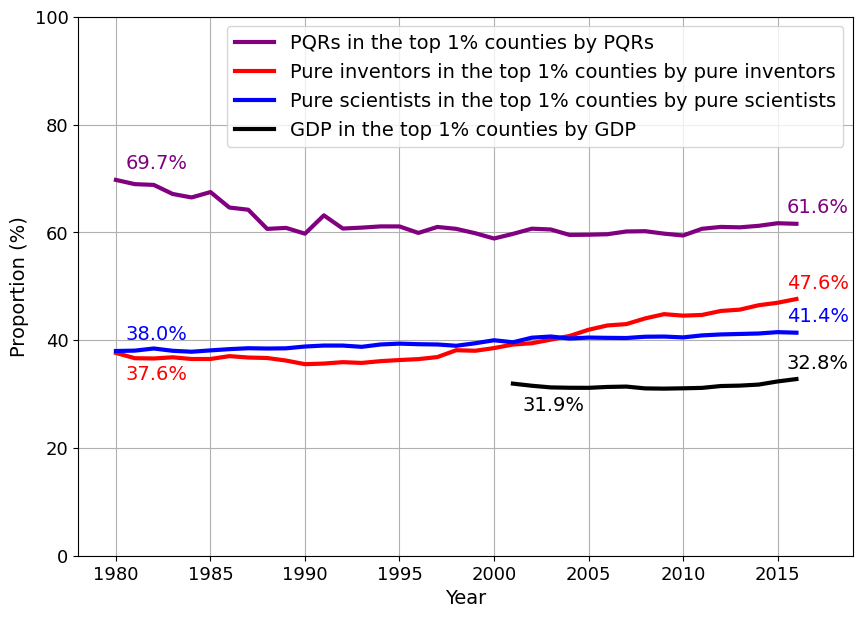

In [16]:
## plot gdp vs proportion of SIs
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'font.size': 13})
plt.figure(figsize = (10,7))

legend = [] 
for value in tqdm([31]):
    color = 'purple'
    k = 1
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        df_gk = pd.DataFrame(dic_year_pqrs[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk.head(value)["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.text(1980.5, Y[0]+2, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]+2, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)
    plt.plot(X,Y,label="PQRs in the top 1% counties by PQRs", color = color,linewidth=3.0)


legend = [] 
for value in tqdm([31]):
    color = 'red'
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        df_gk = pd.DataFrame(dic_year_inventors[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk.head(value)["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.plot(X,Y, color = color,  label='Pure inventors in the top 1% counties by pure inventors',linewidth=3.0)
    plt.text(1980.5, Y[0]-5, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]+2, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)




legend = [] 
for value in tqdm([31]):
    color = 'blue'

    k = 0 
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        df_gk = pd.DataFrame(dic_year_authors[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk.head(value)["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.text(1980.5, Y[0]+2, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]+2, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)
    plt.plot(X,Y, color = color,label="Pure scientists in the top 1% counties by pure scientists",linewidth=3.0)







legend = [] 
for value in tqdm([31]):
    color = 'k'
    X = [ year for year in range(2001,2017)]
    Y = []
    for year in range(2001,2017):
        year = str(year)
        df_gk = df_counties_gk_gdp.sort_values(year, ascending = False)
        sum_gk = sum(df_gk[year])
        prop = sum(df_gk.head(value)[year])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.plot(X,Y, color = color,  label='GDP in the top 1% counties by GDP',linewidth=3.0)
    plt.text(2001.5, Y[0]-5, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]+2, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)






plt.legend(fontsize = 14)
plt.ylim([0,100])
plt.xlabel("Year", fontsize=14)
plt.ylabel("Proportion (%)", fontsize = 14) 
plt.xlim([1978,2019])
plt.xticks([k for k in range(1980,2020,5)])
#plt.title("Evolution of the proportion of the US GDP corresponding to the counties the highest GDP")
plt.grid()
plt.savefig('figures/ConcentrationPQRs.png')
plt.show()

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 16.29it/s]


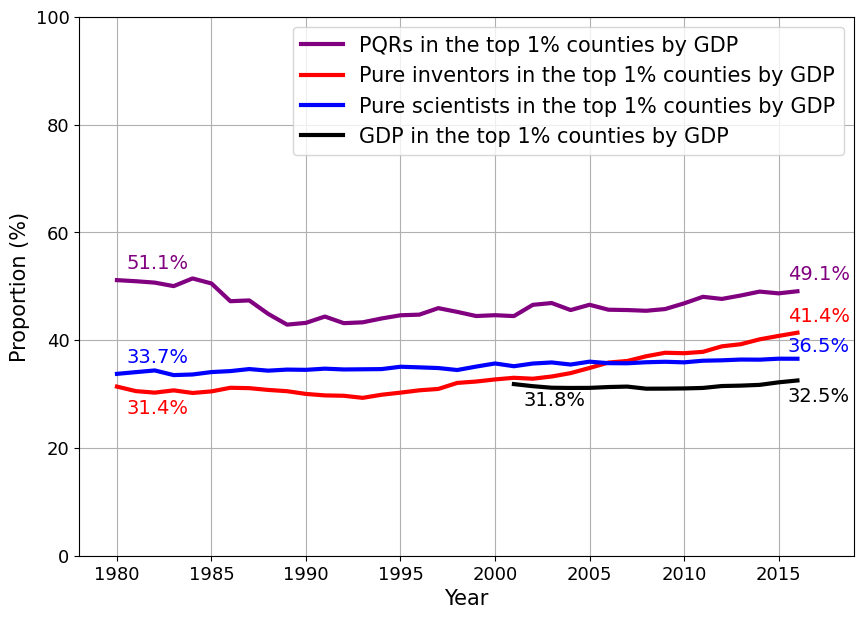

In [15]:
## plot gdp vs proportion of SIs
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'font.size': 13})

plt.figure(figsize = (10,7))

df_counties_gk_gdp['total_gdp'] = sum(df_counties_gk_gdp[str(year)] for year in range(2001,2017))
top1counties = df_counties_gk_gdp.sort_values('total_gdp', ascending = False).head(31)['Fips'].astype(str)


legend = [] 
for value in tqdm([31]):
    color = 'purple'
    k = 1
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        #top1counties = df_counties_gk_gdp.sort_values(str(year), ascending = False).head(value)['Fips'].astype(str)
        df_gk = pd.DataFrame(dic_year_pqrs[year]).T.sort_values("values" , ascending = False)

        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk[df_gk.index.isin(top1counties)]["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(value/3055,1)}%)')
    plt.text(1980.5, Y[0]+2.1, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]+2.1, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)
    plt.plot(X,Y,label="PQRs in the top 1% counties by GDP", color = color,linewidth=3.0)


legend = [] 
for value in tqdm([31]):
    color = 'red'
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        #top1counties = df_counties_gk_gdp.sort_values(str(year), ascending = False).head(value)['Fips'].astype(str)
        df_gk = pd.DataFrame(dic_year_inventors[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk[df_gk.index.isin(top1counties)]["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(value/3055,1)}%)')
    plt.plot(X,Y, color = color,  label='Pure inventors in the top 1% counties by GDP',linewidth=3.0)
    plt.text(1980.5, Y[0]-5, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]+2, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)


legend = [] 
for value in tqdm([31]):
    
    
    color = 'blue'

    k = 0 
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        #top1counties = df_counties_gk_gdp.sort_values(str(year), ascending = False).head(value)['Fips'].astype(str)
        df_gk = pd.DataFrame(dic_year_authors[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk[df_gk.index.isin(top1counties)]["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(value/3055,1)}%)')
    plt.text(1980.5, Y[0]+2, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]+1.3, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)
    plt.plot(X,Y, color = color,label="Pure scientists in the top 1% counties by GDP",linewidth=3.0)






legend = [] 
for value in tqdm([31]):
    color = 'k'
    X = [ year for year in range(2001,2017)]
    Y = []
    for year in range(2001,2017):
        year = str(year)
        df_gk = df_counties_gk_gdp.sort_values(year, ascending = False)
        sum_gk = sum(df_gk[year])
        
        prop = sum(df_gk[df_gk['Fips'].isin([ int(elem) for elem in top1counties])][year])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(value/3055,1)}%)')
    plt.plot(X,Y, color = color,  label='GDP in the top 1% counties by GDP',linewidth=3.0)
    plt.text(2001.5, Y[0]-4, str(round(Y[0],1) ) + "%" , fontsize = 14, color = color)
    plt.text(2015.5, Y[-1]-4, str(round(Y[-1],1) ) + "%" , fontsize = 14, color = color)




plt.legend(fontsize = 15)
plt.ylim([0,100])
plt.xlim([1978,2019])
plt.xlabel("Year", fontsize = 15)
plt.ylabel("Proportion (%)", fontsize = 15) 
plt.xticks([k for k in range(1980,2020,5)])
#plt.title("Evolution of the proportion of the US GDP corresponding to the counties the highest GDP")
plt.grid()
plt.savefig('figures/GDPConcentrationPQRs_v2.png')
plt.show()

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 17.27it/s]


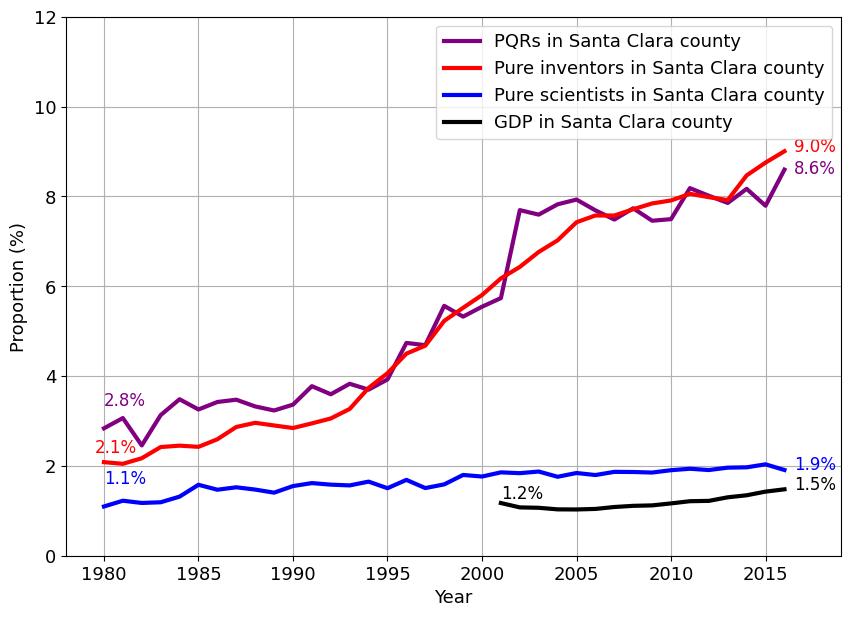

In [17]:
## plot gdp vs proportion of SIs

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'font.size': 13})
santa_clara = '6085'
#santa_clara = '11001'
plt.figure(figsize = (10,7))
legend = [] 


legend = [] 
for value in tqdm([31]):
    color = 'purple'
    k = 1
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        df_gk = pd.DataFrame(dic_year_pqrs[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk[df_gk.index == santa_clara]["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.text(1980, Y[0]+0.5, str(round(Y[0],1) ) + "%" , fontsize = 12, color = color)
    plt.text(2016.5, Y[-1]-0.1, str(round(Y[-1],1) ) + "%" , fontsize = 12, color = color)
    plt.plot(X,Y,label="PQRs in Santa Clara county", color = color,linewidth=3.0)


legend = [] 
for value in tqdm([31]):
    color = 'red'
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        df_gk = pd.DataFrame(dic_year_inventors[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk[df_gk.index == santa_clara]["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.plot(X,Y, color = color,  label='Pure inventors in Santa Clara county',linewidth=3.0)
    plt.text(1979.5, Y[0]+0.2, str(round(Y[0],1) ) + "%" , fontsize = 12, color = color)
    plt.text(2016.5, Y[-1], str(round(Y[-1],1) ) + "%" , fontsize = 12, color = color)



legend = [] 
for value in tqdm([31]):
    color = 'blue'

    k = 0 
    X = [ year for year in range(1980,2017)]
    Y = []
    for year in range(1980,2017):
        year = str(year)
        df_gk = pd.DataFrame(dic_year_authors[year]).T.sort_values("values" , ascending = False)
        sum_gk = sum(df_gk["values"])
        prop = sum(df_gk[df_gk.index == santa_clara]["values"])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.text(1980, Y[0]+0.5, str(round(Y[0],1) ) + "%" , fontsize = 12, color = color)
    plt.text(2016.5, Y[-1], str(round(Y[-1],1) ) + "%" , fontsize = 12, color = color)
    plt.plot(X,Y, color = color,label="Pure scientists in Santa Clara county",linewidth=3.0)





legend = [] 
for value in tqdm([31]):
    color = 'k'
    X = [ year for year in range(2001,2017)]
    Y = []
    for year in range(2001,2017):
        year = str(year)
        df_gk = df_counties_gk_gdp.sort_values(year, ascending = False)
        sum_gk = sum(df_gk[year])
        prop = sum(df_gk[df_gk['Fips'] == int(santa_clara)][year])/sum_gk
        Y.append(100*prop)
    legend.append(f'Top {value} counties ({round(100*value/3055,1)}%)')
    plt.plot(X,Y, color = color,  label='GDP in Santa Clara county',linewidth=3.0)
    plt.text(2001, Y[0]+0.1, str(round(Y[0],1) ) + "%" , fontsize = 12, color = color)
    plt.text(2016.5, Y[-1], str(round(Y[-1],1) ) + "%" , fontsize = 12, color = color)






plt.legend()
plt.ylim([0,12])
plt.xlabel("Year")
plt.ylabel("Proportion (%)") 
plt.xlim([1978,2019])
plt.xticks([k for k in range(1980,2020,5)])
#plt.title("Evolution of the proportion of the US GDP corresponding to the counties the highest GDP")
plt.grid()
plt.savefig('figures/SantaClaraPQRs.png')
plt.show()

### Gini coefficients

In [9]:
def gini(x):
    # (Warning: This is a concise implementation, but it is O(n**2)
    # in time and memory, where n = len(x).  *Don't* pass in huge
    # samples!)

    # Mean absolute difference
    mad = np.abs(np.subtract.outer(x, x)).mean()
    # Relative mean absolute difference
    rmad = mad/np.mean(x)
    # Gini coefficient
    g = 0.5 * rmad
    return g

In [10]:
## calculate the gini coefficient for each year

dic_gini_authors = { year : 0 for year in range(1980,2017) }
dic_gini_inventors = { year : 0 for year in range(1980,2017) }
dic_gini_pqrs = { year : 0 for year in range(1980,2017) }

counties_per_year_authors  = { year : np.zeros((3055)) for year in range(1980,2017) }
counties_per_year_inventors  = { year : np.zeros((3055)) for year in range(1980,2017) }
counties_per_year_PQRs  = { year : np.zeros((3055)) for year in range(1980,2017) }

for year in tqdm(range(1980,2017)):

    val_authors = np.array(list(dic_year_authors[str(year)].values()))
    val_inventors = list(dic_year_inventors[str(year)].values())
    val_PQRs = list(dic_year_pqrs[str(year)].values())

    
    for k in range(len(dic_year_authors[str(year)])):
        counties_per_year_authors[year][k] = val_authors[k]['values']

    dic_year_inventors[str(year)] = { k : v for k,v in sorted(dic_year_inventors[str(year)].items(), key = lambda item : item[1]['values'], reverse = True ) } 
    for k in range(min(len(dic_year_inventors[str(year)]),3055)):
        counties_per_year_inventors[year][k] = val_inventors[k]['values']

    for k in range(len(dic_year_pqrs[str(year)])):
        counties_per_year_PQRs[year][k] = val_PQRs[k]['values']
    
    dic_gini_authors[year] = gini(counties_per_year_authors[year])
    dic_gini_inventors[year] = gini(counties_per_year_inventors[year])
    dic_gini_pqrs[year] = gini(counties_per_year_PQRs[year])
            


100%|███████████████████████████████████████████| 37/37 [00:03<00:00,  9.99it/s]


In [11]:
dic_gini_gdp = { year : 0 for year in range(2001,2017) }

for year in range(2001,2017):
    dic_gini_gdp[year] = gini(list(df_counties_gk_gdp[str(year)]))

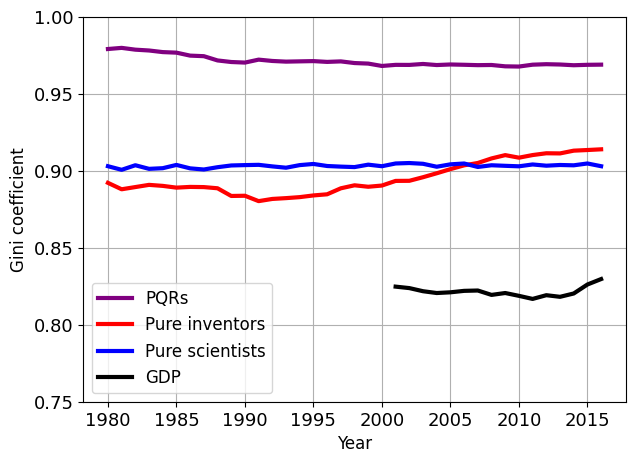

In [14]:
## plot gini coefficient 

plt.figure(figsize = (7,5))
plt.plot(dic_gini_pqrs.keys() , dic_gini_pqrs.values(), color = 'purple',linewidth=3.0)
plt.plot(dic_gini_inventors.keys() , dic_gini_inventors.values(),color='red',linewidth=3.0)
plt.plot(dic_gini_authors.keys() , dic_gini_authors.values(),color='blue',linewidth=3.0)
plt.plot(dic_gini_gdp.keys() , dic_gini_gdp.values(),color='k',linewidth=3.0)

plt.ylim([0.75,1])
plt.xlabel("Year",fontsize = 12)
plt.ylabel("Gini coefficient",fontsize = 12)
#plt.title("Gini coefficient by counties - active GateKeepers")
#plt.xlim([1980,2016])
plt.grid()
plt.legend(['PQRs','Pure inventors','Pure scientists','GDP'], fontsize = 12)
plt.savefig('figures/gini_05.png')
plt.show()


In [ ]:

plt.figure(figsize = (7,5))
plt.plot(dic_gini_pqrs.keys() , dic_gini_pqrs.values())
plt.plot(dic_gini_authors.keys() , dic_gini_authors.values())
plt.plot(dic_gini_inventors.keys() , dic_gini_inventors.values())
plt.plot(dic_gini_gdp.keys() , dic_gini_gdp.values())

plt.ylim([0,1])
plt.xlabel("Year",fontsize = 12)
plt.ylabel("Gini coefficient",fontsize = 12)
#plt.title("Gini coefficient by counties - active GateKeepers")
#plt.xlim([1980,2016])
plt.legend(['PQRs','Pure scientists','Pure inventors','GDP'],fontsize = 12)
plt.show()
